# MDR-TS v20.3
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v20.3
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/derived_8.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

- Combating variance and heteroscedasticity.

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier

import torch

import statsmodels.api as sm
import statsmodels.stats.api as sms

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)

from Utils.dashboard import metrics_dashboard

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

sns.set_theme(style="whitegrid", context="talk")
sns.set_style("ticks")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v20"
SUBVERSION = "v20.3"
RUN_NAME = "mdr_ts_v20_3"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v20/v20.3

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_8.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_8.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_8.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 499

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [6]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS_BASE = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",

    "A_d_E_SAR_diff_kobs14",

    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",

    "V_rollmean_s2_b11_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "V_rollmean_s2_b11_kobs7",

    "year_frac", "sin_year", "cos_year",
]

FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",

    "slope", "elev",
]

def _check_cols(df, cols, name):
    missing = sorted(set(cols) - set(df.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

for _df_name, _df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    _check_cols(_df, KEEP_META_COLS + [TARGET_COL], _df_name)
    _check_cols(_df, FEATURE_COLS_BASE, f"{_df_name} (BASE)")
    _check_cols(_df, FEATURE_COLS_DRY, f"{_df_name} (DRY)")
    _check_cols(_df, FEATURE_COLS_WET, f"{_df_name} (WET)")

print("Columns locked")
print("  BASE features:", len(FEATURE_COLS_BASE))
print("  DRY  features:", len(FEATURE_COLS_DRY))
print("  WET  features:", len(FEATURE_COLS_WET))
print("  Target:", TARGET_COL)

Columns locked
  BASE features: 28
  DRY  features: 21
  WET  features: 26
  Target: soil_moisture_5cm


In [7]:
def get_metrics_dict(y_true, y_pred, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = float(r2_score(y_true, y_pred))
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(root_mean_squared_error(y_true, y_pred))

    bias = float(np.mean(err))
    ubrmse = float(np.std(err))

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])

    return {
        f"{prefix}n": int(len(y_true)),
        f"{prefix}r2": r2,
        f"{prefix}mae": mae,
        f"{prefix}rmse": rmse,
        f"{prefix}ubrmse": ubrmse,
        f"{prefix}bias": bias,
        f"{prefix}med_ae": float(np.median(ae)),
        f"{prefix}p90_ae": float(np.quantile(ae, 0.90)),
        f"{prefix}q05_err": float(q_err[0]),
        f"{prefix}q50_err": float(q_err[2]),
        f"{prefix}q95_err": float(q_err[4]),
    }

def neat_print(metrics, title=None, decimals=5):
    preferred_order = [
        "n", "r2", "mae", "rmse", "ubrmse", "bias",
        "med_ae", "p90_ae",
        "q05_err", "q50_err", "q95_err",
    ]

    keys = list(metrics.keys())
    if "_" in keys[0]:
        prefix = keys[0].split("_")[0] + "_"
    else:
        prefix = ""

    ordered_keys = []
    for k in preferred_order:
        full_key = prefix + k
        if full_key in metrics:
            ordered_keys.append(full_key)

    for k in metrics:
        if k not in ordered_keys:
            ordered_keys.append(k)

    if title:
        print(f"\n{title}")
    print("=" * 42)
    print(f"{'Metric':<18} {'Value':>18}")
    print("-" * 42)

    for k in ordered_keys:
        v = metrics[k]

        if isinstance(v, int):
            val_str = f"{v:,}"
        else:
            val_str = f"{v:.{decimals}f}"

        print(f"{k:<18} {val_str:>18}")

    print("=" * 42)

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [8]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     6868
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2017-01-01 -- 2020-12-31

VAL
  rows:     2720
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [9]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_base = trainval_df_d[FEATURE_COLS_BASE].copy()
y_trainval = trainval_df_d[TARGET_COL].copy()

X_test_base = test_df[FEATURE_COLS_BASE].copy()
y_test = test_df[TARGET_COL].copy()

X_trainval_dry = trainval_df_d[FEATURE_COLS_DRY].copy()
X_test_dry = test_df[FEATURE_COLS_DRY].copy()

X_trainval_wet = trainval_df_d[FEATURE_COLS_WET].copy()
X_test_wet = test_df[FEATURE_COLS_WET].copy()

print("\nMatrix shapes:")
print("  BASE trainval:", X_trainval_base.shape)
print("  DRY  trainval:", X_trainval_dry.shape)
print("  WET  trainval:", X_trainval_wet.shape)
print("  BASE test:    ", X_test_base.shape)
print("  DRY  test:    ", X_test_dry.shape)
print("  WET  test:    ", X_test_wet.shape)


Matrix shapes:
  BASE trainval: (9588, 28)
  DRY  trainval: (9588, 21)
  WET  trainval: (9588, 26)
  BASE test:     (4016, 28)
  DRY  test:     (4016, 21)
  WET  test:     (4016, 26)


### Inner Split

In [10]:
y_tv = np.asarray(y_trainval).ravel()

n = len(y_tv)
cut = int(0.8 * n)  # last 20% is inner-val

idx_tr = np.arange(0, cut)
idx_va = np.arange(cut, n)

print("Inner split sizes:")
print("  train:", len(idx_tr))
print("  val:  ", len(idx_va))

Inner split sizes:
  train: 7670
  val:   1918


In [11]:
t1 = 0.20
t2 = 0.313

reg_tv = np.zeros_like(y_tv, dtype=int)
reg_tv[(y_tv > t1) & (y_tv <= t2)] = 1
reg_tv[y_tv > t2] = 2

# masks per regime for inner train/val
masks = {}
for r in [0, 1, 2]:
    masks[r] = {
        "tr": (reg_tv[idx_tr] == r),
        "va": (reg_tv[idx_va] == r),
    }
    print(r, "inner-tr:", masks[r]["tr"].sum(), "inner-va:", masks[r]["va"].sum())

0 inner-tr: 3577 inner-va: 703
1 inner-tr: 3094 inner-va: 791
2 inner-tr: 999 inner-va: 424


### Base Model

In [12]:
XGB_PARAMS_DRY = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

XGB_PARAMS_TRANSITION = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.85,
    n_estimators=8000,
    learning_rate=0.03,
    reg_lambda=3.0,
    reg_alpha=0.05,
)

XGB_PARAMS_WET = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    max_depth=10,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.9,
    n_estimators=6000,
    learning_rate=0.03,
    reg_lambda=0.3,
    reg_alpha=0.0,
)

In [13]:
xgb_dry = XGBRegressor(**XGB_PARAMS_DRY)
xgb_transition = XGBRegressor(**XGB_PARAMS_TRANSITION)
xgb_wet = XGBRegressor(**XGB_PARAMS_WET)

mask_dry = reg_tv == 0
mask_transition = reg_tv == 1
mask_wet = reg_tv == 2

In [14]:
xgb_dry.fit(X_trainval_base, y_trainval, verbose=0)

pred_dry_tv = xgb_dry.predict(X_trainval_base)   # length = len(trainval)
pred_dry_test = xgb_dry.predict(X_test_base)     # length = len(test)

In [15]:
X_tv_aug = np.column_stack([X_trainval_wet, pred_dry_tv])
X_test_aug = np.column_stack([X_test_wet, pred_dry_test])

xgb_transition.fit(
    X_tv_aug[mask_transition],
    y_trainval[mask_transition],
    verbose=0
)

pred_transition = xgb_transition.predict(X_test_aug)

In [16]:
xgb_wet.fit(
    X_tv_aug[mask_wet],
    y_trainval[mask_wet],
    verbose=0
)
pred_wet = xgb_wet.predict(X_test_aug)

In [17]:
y_test_arr = np.asarray(y_test).ravel()

reg_test = np.zeros_like(y_test_arr, dtype=int)
reg_test[(y_test_arr > t1) & (y_test_arr <= t2)] = 1
reg_test[y_test_arr > t2] = 2

mask_dry_test = reg_test == 0
mask_transition_test = reg_test == 1
mask_wet_test = reg_test == 2

print("Test regime counts:")
print("  dry:", mask_dry_test.sum())
print("  transition:", mask_transition_test.sum())
print("  wet:", mask_wet_test.sum())

Test regime counts:
  dry: 1509
  transition: 2015
  wet: 492


In [18]:
metrics_dashboard(
    y_test_arr[mask_dry_test],
    np.asarray(pred_dry_test).ravel()[mask_dry_test],
    name="DRY REGIME (Base/Anchor) - slice",
    return_dict=False
)

In [19]:
neat_print(get_metrics_dict(y_test_arr[mask_dry_test], np.asarray(pred_dry_test).ravel()[mask_dry_test], prefix=""), "DRY REGIME")


DRY REGIME
Metric                          Value
------------------------------------------
n                               1,509
r2                            0.33437
mae                           0.03288
rmse                          0.04525
ubrmse                        0.03919
bias                         -0.02262
med_ae                        0.02253
p90_ae                        0.07470
q05_err                      -0.09031
q50_err                      -0.01637
q95_err                       0.03918


In [20]:
metrics_dashboard(
    y_test_arr[mask_transition_test],
    np.asarray(pred_transition).ravel()[mask_transition_test],
    name="TRANSITION specialist - slice",
    return_dict=False
)

In [21]:
neat_print(get_metrics_dict(y_test_arr[mask_transition_test], np.asarray(pred_transition).ravel()[mask_transition_test], prefix=""), "TRANSITION REGIME")


TRANSITION REGIME
Metric                          Value
------------------------------------------
n                               2,015
r2                            0.14745
mae                           0.02331
rmse                          0.02997
ubrmse                        0.02990
bias                         -0.00204
med_ae                        0.01929
p90_ae                        0.04969
q05_err                      -0.05511
q50_err                      -0.00083
q95_err                       0.04632


In [22]:
metrics_dashboard(
    y_test_arr[mask_wet_test],
    np.asarray(pred_wet).ravel()[mask_wet_test],
    name="WET specialist - slice",
    return_dict=False
)

In [23]:
neat_print(get_metrics_dict(y_test_arr[mask_wet_test], np.asarray(pred_wet).ravel()[mask_wet_test], prefix=""), "WET REGIME")


WET REGIME
Metric                          Value
------------------------------------------
n                                 492
r2                           -0.31852
mae                           0.01181
rmse                          0.01659
ubrmse                        0.01612
bias                          0.00395
med_ae                        0.00807
p90_ae                        0.02969
q05_err                      -0.01742
q50_err                       0.00048
q95_err                       0.03788


In [24]:
neat_print(get_metrics_dict(y_test_arr[mask_dry_test], np.asarray(pred_dry_test).ravel()[mask_dry_test], prefix=""), "DRY REGIME")
neat_print(get_metrics_dict(y_test_arr[mask_transition_test], np.asarray(pred_transition).ravel()[mask_transition_test], prefix=""), "TRANSITION REGIME")
neat_print(get_metrics_dict(y_test_arr[mask_wet_test], np.asarray(pred_wet).ravel()[mask_wet_test], prefix=""), "WET REGIME")


DRY REGIME
Metric                          Value
------------------------------------------
n                               1,509
r2                            0.33437
mae                           0.03288
rmse                          0.04525
ubrmse                        0.03919
bias                         -0.02262
med_ae                        0.02253
p90_ae                        0.07470
q05_err                      -0.09031
q50_err                      -0.01637
q95_err                       0.03918

TRANSITION REGIME
Metric                          Value
------------------------------------------
n                               2,015
r2                            0.14745
mae                           0.02331
rmse                          0.02997
ubrmse                        0.02990
bias                         -0.00204
med_ae                        0.01929
p90_ae                        0.04969
q05_err                      -0.05511
q50_err                      -0.00083
q95_err  

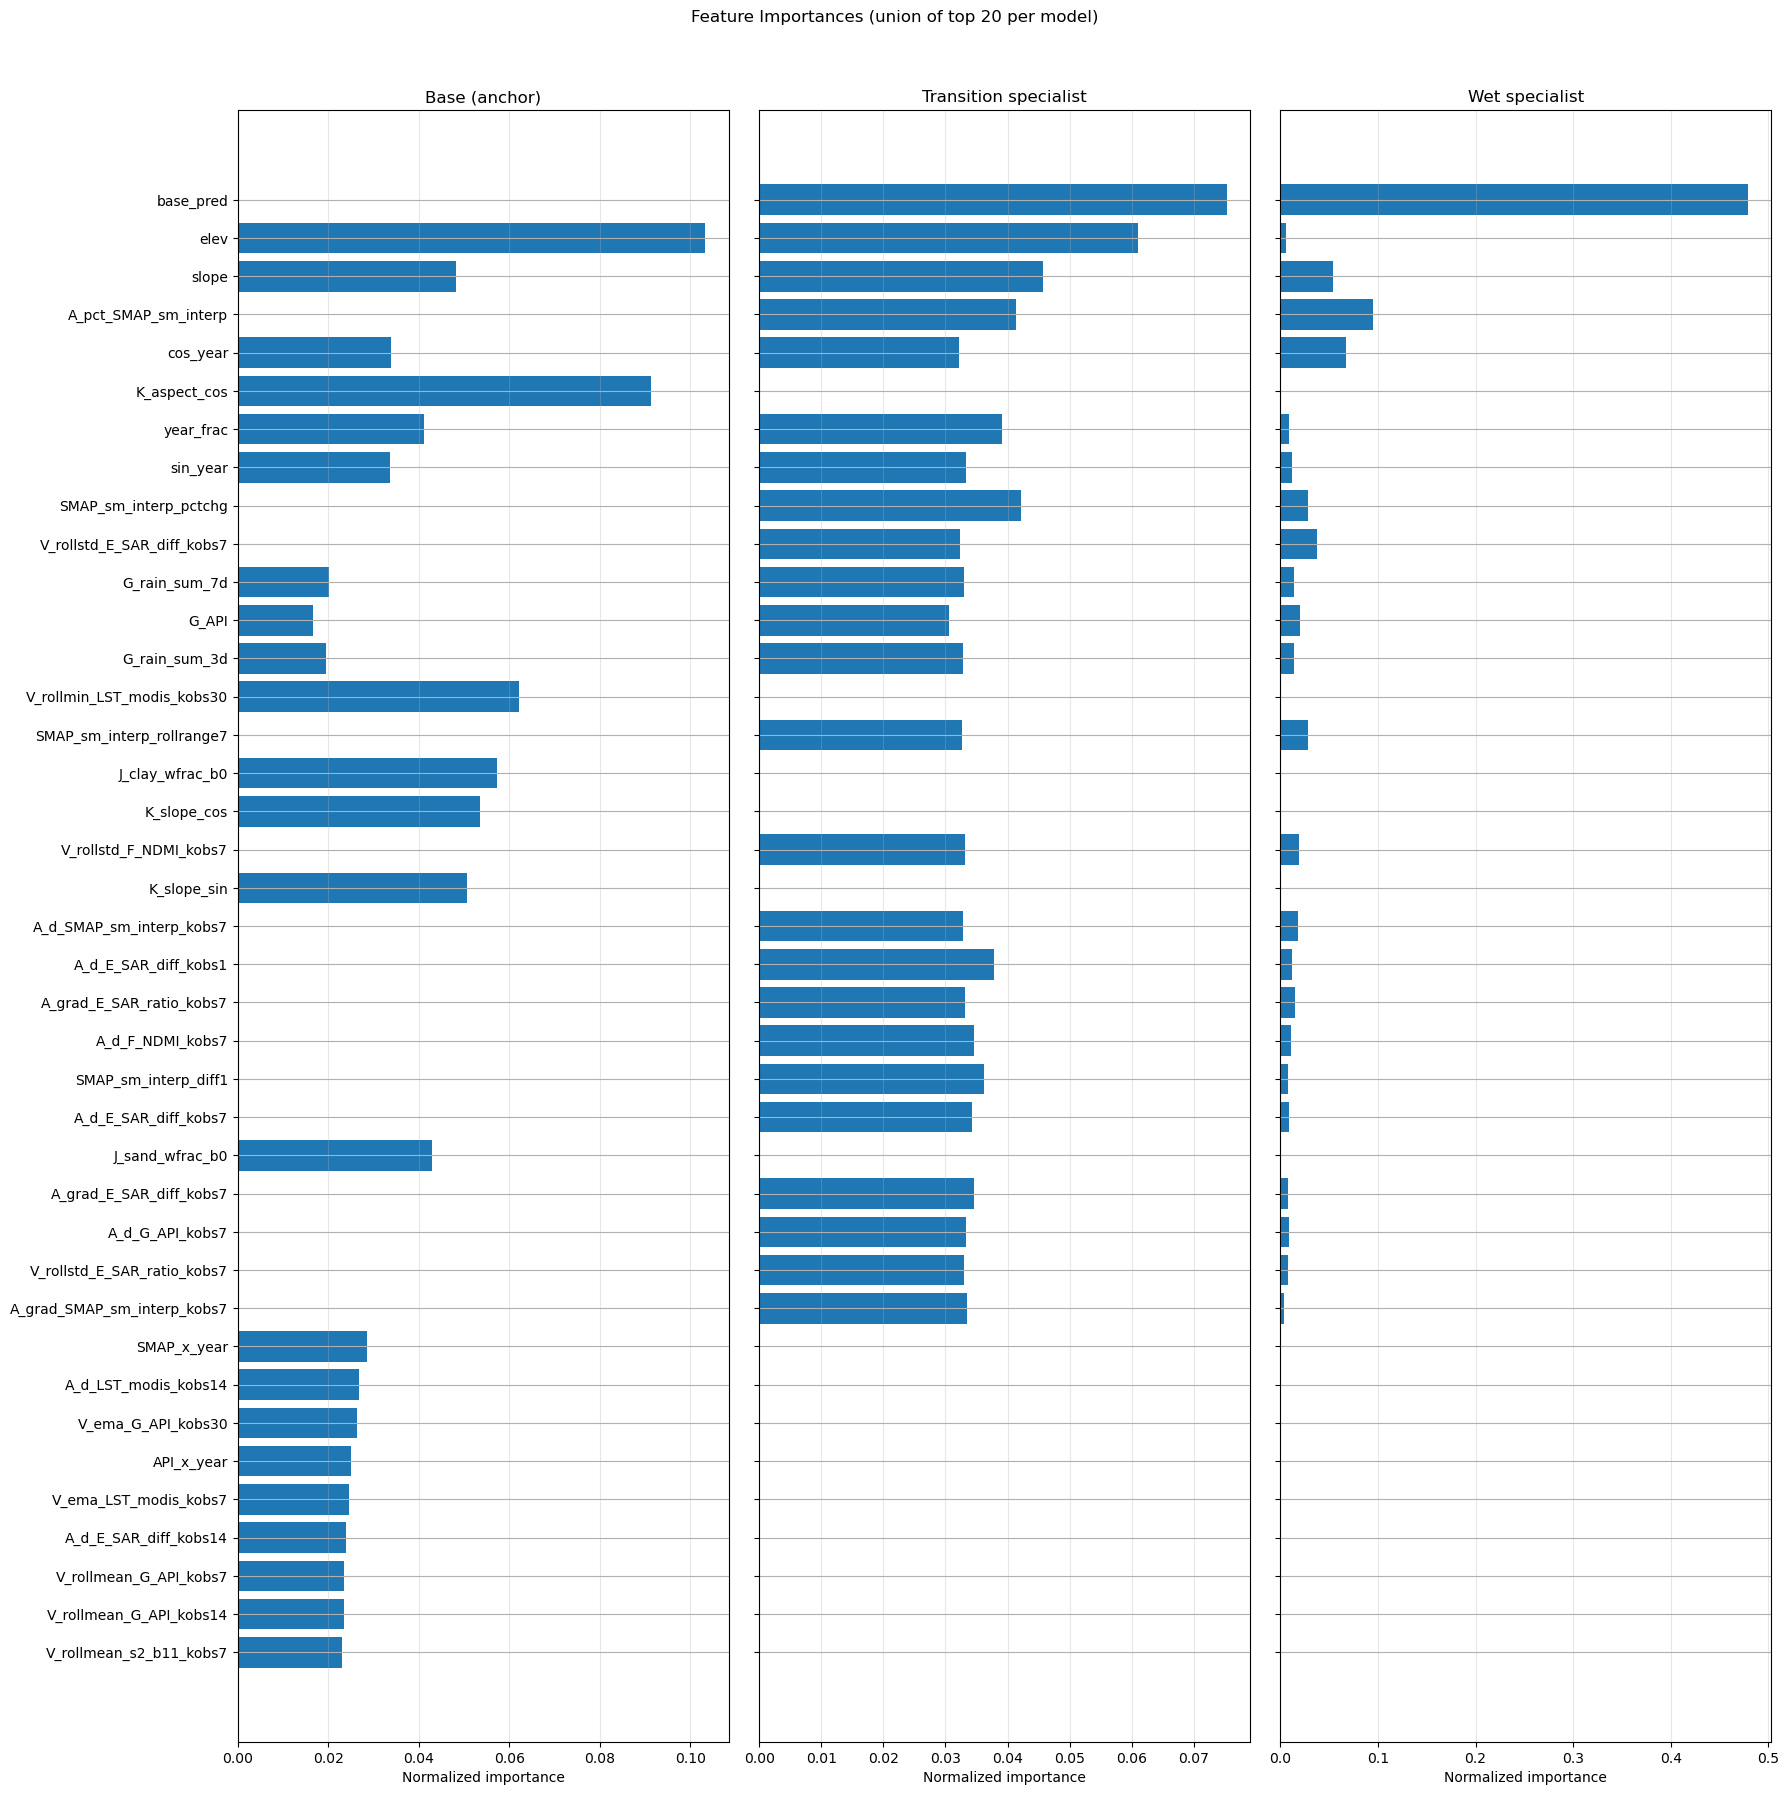

In [25]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    s = imp.sum()
    if s > 0:
        imp = imp / s
    return imp

TOP_K = 20

cols_base = list(FEATURE_COLS_BASE)
cols_aug = list(FEATURE_COLS_WET) + ["base_pred"]

imp_base = get_xgb_importance(xgb_dry, cols_base)
imp_trn  = get_xgb_importance(xgb_transition, cols_aug)
imp_wet  = get_xgb_importance(xgb_wet, cols_aug)

top_feats = sorted(set(
    imp_base.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_trn.sort_values(ascending=False).head(TOP_K).index
) | set(
    imp_wet.sort_values(ascending=False).head(TOP_K).index
))

cmp = pd.DataFrame({
    "base": imp_base.reindex(top_feats, fill_value=0.0),
    "transition": imp_trn.reindex(top_feats, fill_value=0.0),
    "wet": imp_wet.reindex(top_feats, fill_value=0.0),
})

cmp["mean"] = cmp[["base", "transition", "wet"]].mean(axis=1)
cmp = cmp.sort_values("mean", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, max(6, 0.45 * len(cmp))), sharey=True)

y = np.arange(len(cmp))

axes[0].barh(y, cmp["base"].values)
axes[0].set_title("Base (anchor)")
axes[0].set_xlabel("Normalized importance")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(y, cmp["transition"].values)
axes[1].set_title("Transition specialist")
axes[1].set_xlabel("Normalized importance")
axes[1].grid(axis="x", alpha=0.3)

axes[2].barh(y, cmp["wet"].values)
axes[2].set_title("Wet specialist")
axes[2].set_xlabel("Normalized importance")
axes[2].grid(axis="x", alpha=0.3)

axes[0].set_yticks(y)
axes[0].set_yticklabels(cmp.index)

plt.suptitle(f"Feature Importances (union of top {TOP_K} per model)", y=1.02)
plt.tight_layout()
plt.show()

In [26]:
print(cmp["wet"])

V_rollmean_s2_b11_kobs7        0.000000
V_rollmean_G_API_kobs14        0.000000
V_rollmean_G_API_kobs7         0.000000
A_d_E_SAR_diff_kobs14          0.000000
V_ema_LST_modis_kobs7          0.000000
API_x_year                     0.000000
V_ema_G_API_kobs30             0.000000
A_d_LST_modis_kobs14           0.000000
SMAP_x_year                    0.000000
A_grad_SMAP_sm_interp_kobs7    0.003631
V_rollstd_E_SAR_ratio_kobs7    0.007528
A_d_G_API_kobs7                0.008940
A_grad_E_SAR_diff_kobs7        0.007790
J_sand_wfrac_b0                0.000000
A_d_E_SAR_diff_kobs7           0.008860
SMAP_sm_interp_diff1           0.007356
A_d_F_NDMI_kobs7               0.011067
A_grad_E_SAR_ratio_kobs7       0.014575
A_d_E_SAR_diff_kobs1           0.012060
A_d_SMAP_sm_interp_kobs7       0.017699
K_slope_sin                    0.000000
V_rollstd_F_NDMI_kobs7         0.018588
K_slope_cos                    0.000000
J_clay_wfrac_b0                0.000000
SMAP_sm_interp_rollrange7      0.028045


### Residuals

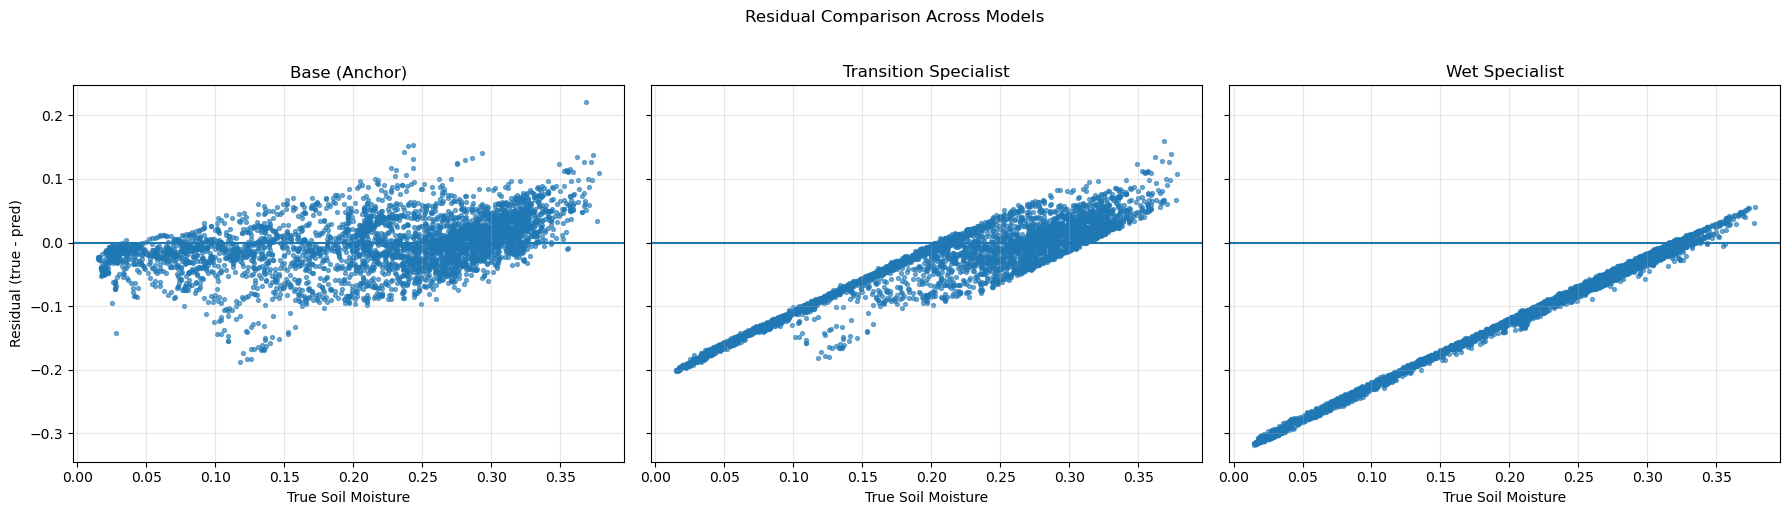

In [27]:
y_true = np.asarray(y_test).ravel()

pred_base = np.asarray(pred_dry_test).ravel()
pred_trn  = np.asarray(pred_transition).ravel()
pred_wet  = np.asarray(pred_wet).ravel()

res_base = y_true - pred_base
res_trn  = y_true - pred_trn
res_wet  = y_true - pred_wet

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_true, res_base, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_title("Base (Anchor)")
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true, res_trn, s=8, alpha=0.6)
axes[1].axhline(0)
axes[1].set_title("Transition Specialist")
axes[1].set_xlabel("True Soil Moisture")
axes[1].grid(alpha=0.3)

axes[2].scatter(y_true, res_wet, s=8, alpha=0.6)
axes[2].axhline(0)
axes[2].set_title("Wet Specialist")
axes[2].set_xlabel("True Soil Moisture")
axes[2].grid(alpha=0.3)

plt.suptitle("Residual Comparison Across Models", y=1.02)
plt.tight_layout()
plt.show()

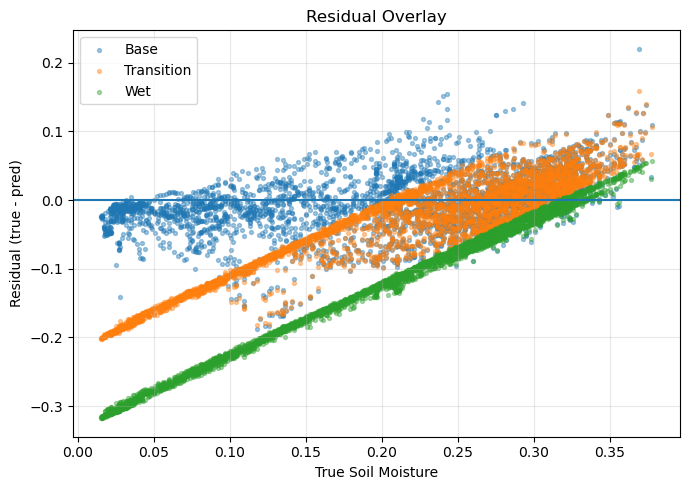

In [28]:
plt.figure(figsize=(7, 5))

plt.scatter(y_true, res_base, s=8, alpha=0.4, label="Base")
plt.scatter(y_true, res_trn,  s=8, alpha=0.4, label="Transition")
plt.scatter(y_true, res_wet,  s=8, alpha=0.4, label="Wet")

plt.axhline(0)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residual Overlay")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
metrics_dashboard(y_test, pred_dry_test, name="BASE (anchor) - global", return_dict=False)
metrics_dashboard(y_test, pred_transition, name="TRANSITION specialist - global", return_dict=False)
metrics_dashboard(y_test, pred_wet, name="WET specialist - global", return_dict=False)

In [30]:
y_test_arr = np.asarray(y_test).ravel()
pred_final = np.zeros_like(y_test_arr, dtype=float)
pred_final[mask_dry_test] = np.asarray(pred_dry_test).ravel()[mask_dry_test]
pred_final[mask_transition_test] = np.asarray(pred_transition).ravel()[mask_transition_test]
pred_final[mask_wet_test] = np.asarray(pred_wet).ravel()[mask_wet_test]

metrics_dashboard(y_test_arr, pred_final, name="FINAL | Hard Gated, Eval-Only", return_dict=False)

In [31]:
neat_print(get_metrics_dict(y_test_arr, pred_final, prefix=""), "FINAL GATED")


FINAL GATED
Metric                          Value
------------------------------------------
n                               4,016
r2                            0.85860
mae                           0.02550
rmse                          0.03541
ubrmse                        0.03423
bias                         -0.00904
med_ae                        0.01837
p90_ae                        0.05776
q05_err                      -0.07135
q50_err                      -0.00651
q95_err                       0.04343


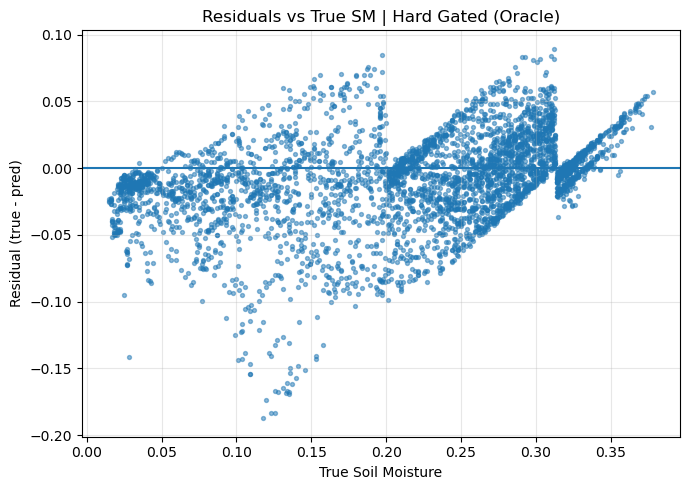

In [32]:
y_true = np.asarray(y_test_arr).ravel()
y_pred = np.asarray(pred_final).ravel()
residuals = y_true - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_true, residuals, s=8, alpha=0.5)
plt.axhline(0)
plt.xlabel("True Soil Moisture")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True SM | Hard Gated (Oracle)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
dfp = pd.DataFrame({
    "y_true": np.asarray(y_test_arr).ravel(),
    "pred_dry": np.asarray(pred_dry_test).ravel(),
    "pred_transition": np.asarray(pred_transition).ravel(),
    "pred_wet": np.asarray(pred_wet).ravel(),
    "pred_final": np.asarray(pred_final).ravel(),
})

dfp["resid_dry"] = dfp["y_true"] - dfp["pred_dry"]
dfp["resid_transition"] = dfp["y_true"] - dfp["pred_transition"]
dfp["resid_wet"] = dfp["y_true"] - dfp["pred_wet"]
dfp["resid_final"] = dfp["y_true"] - dfp["pred_final"]

if "G_API" in test_df.columns:
    dfp["G_API"] = test_df["G_API"].values
if "year_frac" in test_df.columns:
    dfp["year_frac"] = test_df["year_frac"].values
if "date" in test_df.columns:
    dfp["date"] = pd.to_datetime(test_df["date"])

id_vars = ["y_true"]
for c in ["G_API", "year_frac", "date"]:
    if c in dfp.columns:
        id_vars.append(c)

long_resid = dfp.melt(
    id_vars=id_vars,
    value_vars=["resid_dry", "resid_transition", "resid_wet", "resid_final"],
    var_name="model",
    value_name="resid",
)

long_resid["model"] = long_resid["model"].map({
    "resid_dry": "Dry expert",
    "resid_transition": "Transition expert",
    "resid_wet": "Wet expert",
    "resid_final": "Final (gated)",
})

palette = {
    "Dry expert": "#1f77b4",
    "Transition expert": "#2ca02c",
    "Wet expert": "#ff7f0e",
    "Final (gated)": "#d62728",
}

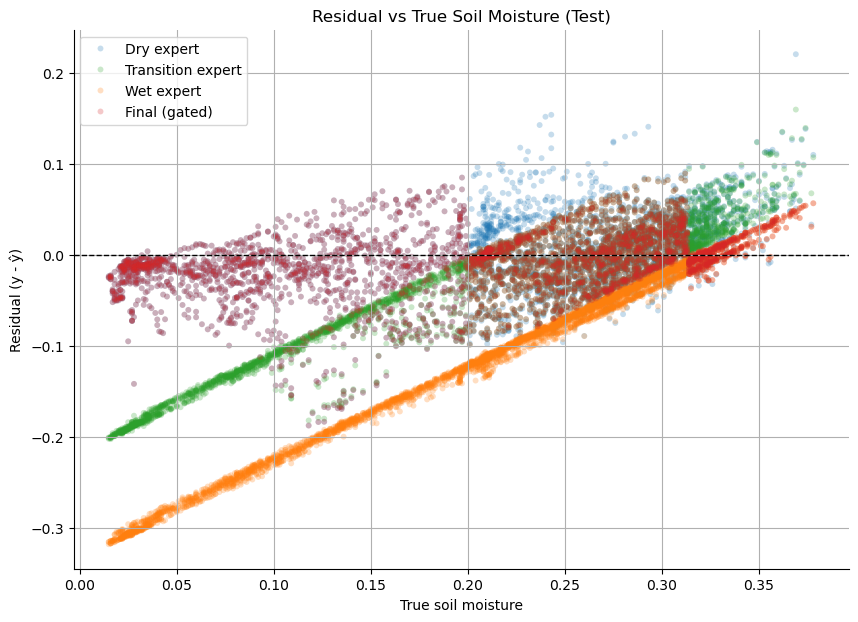

In [34]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=long_resid,
    x="y_true", y="resid",
    hue="model", palette=palette,
    alpha=0.25, s=18, linewidth=0
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("True soil moisture")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residual vs True Soil Moisture (Test)")
sns.despine()
plt.legend(title="", frameon=True)
plt.show()

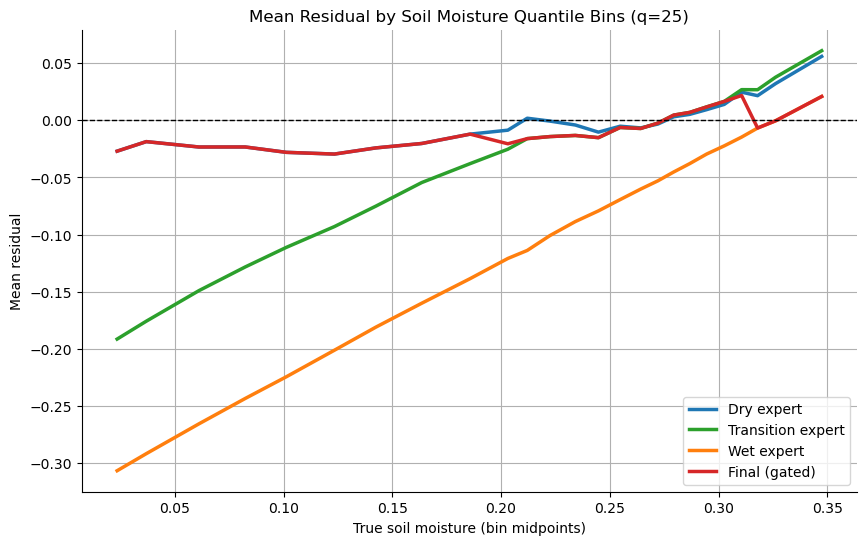

In [35]:
bins = 25
dfp["y_bin"] = pd.qcut(dfp["y_true"], q=bins, duplicates="drop")

bin_means = dfp.groupby("y_bin").agg(
    y_mid=("y_true", "mean"),
    dry_mean=("resid_dry", "mean"),
    transition_mean=("resid_transition", "mean"),
    wet_mean=("resid_wet", "mean"),
    final_mean=("resid_final", "mean"),
).reset_index(drop=True)

trend = bin_means.melt(
    id_vars=["y_mid"],
    value_vars=["dry_mean", "transition_mean", "wet_mean", "final_mean"],
    var_name="model",
    value_name="mean_resid",
)

trend["model"] = trend["model"].map({
    "dry_mean": "Dry expert",
    "transition_mean": "Transition expert",
    "wet_mean": "Wet expert",
    "final_mean": "Final (gated)",
})

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=trend, x="y_mid", y="mean_resid",
    hue="model", palette=palette, linewidth=2.5
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("True soil moisture (bin midpoints)")
plt.ylabel("Mean residual")
plt.title(f"Mean Residual by Soil Moisture Quantile Bins (q={bins})")
sns.despine()
plt.legend(title="", frameon=True)
plt.show()

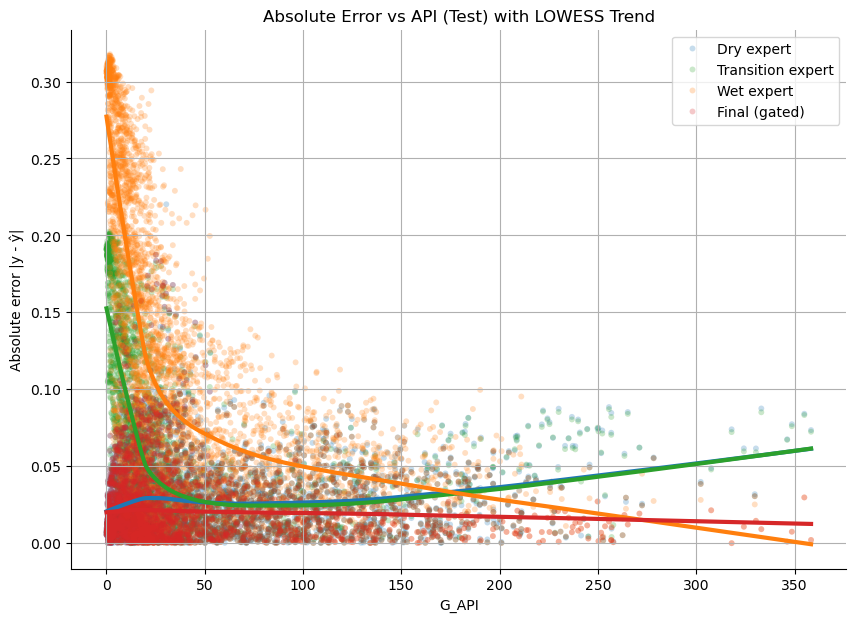

In [36]:
if "G_API" in dfp.columns:
    df_api = pd.DataFrame({
        "G_API": dfp["G_API"],
        "Dry expert": np.abs(dfp["resid_dry"]),
        "Transition expert": np.abs(dfp["resid_transition"]),
        "Wet expert": np.abs(dfp["resid_wet"]),
        "Final (gated)": np.abs(dfp["resid_final"]),
    }).melt(id_vars=["G_API"], var_name="model", value_name="abs_err")

    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        data=df_api, x="G_API", y="abs_err",
        hue="model", palette=palette,
        alpha=0.25, s=18, linewidth=0
    )

    for m in ["Dry expert", "Transition expert", "Wet expert", "Final (gated)"]:
        sns.regplot(
            data=df_api[df_api["model"] == m],
            x="G_API", y="abs_err",
            scatter=False,
            lowess=True,
            color=palette[m],
            line_kws={"linewidth": 3}
        )

    plt.xlabel("G_API")
    plt.ylabel("Absolute error |y - ŷ|")
    plt.title("Absolute Error vs API (Test) with LOWESS Trend")
    sns.despine()
    plt.legend(title="", frameon=True)
    plt.show()

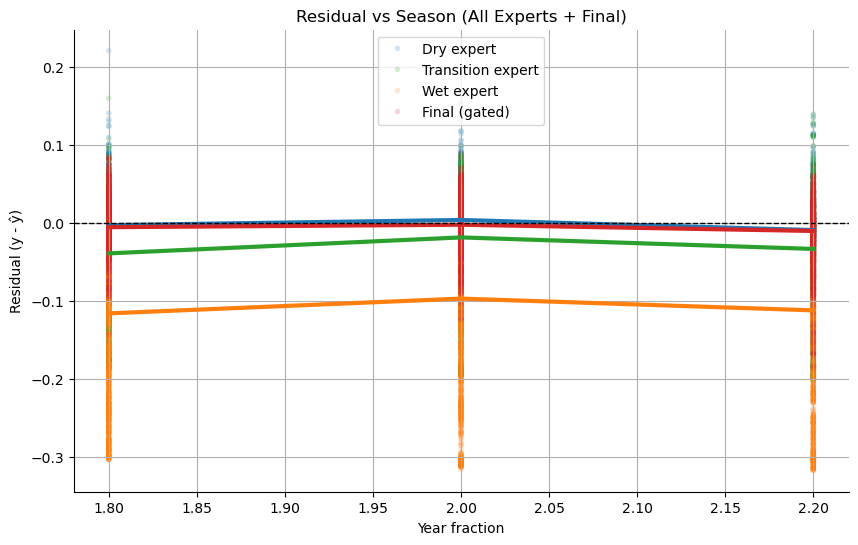

In [37]:
if "year_frac" in dfp.columns:
    df_season = dfp.melt(
        id_vars=["year_frac"],
        value_vars=["resid_dry", "resid_transition", "resid_wet", "resid_final"],
        var_name="model",
        value_name="resid"
    )

    df_season["model"] = df_season["model"].map({
        "resid_dry": "Dry expert",
        "resid_transition": "Transition expert",
        "resid_wet": "Wet expert",
        "resid_final": "Final (gated)",
    })

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df_season,
        x="year_frac", y="resid",
        hue="model", palette=palette,
        alpha=0.2, s=16, linewidth=0
    )

    for m in ["Dry expert", "Transition expert", "Wet expert", "Final (gated)"]:
        sns.regplot(
            data=df_season[df_season["model"] == m],
            x="year_frac", y="resid",
            scatter=False,
            lowess=True,
            color=palette[m],
            line_kws={"linewidth": 3}
        )

    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Year fraction")
    plt.ylabel("Residual (y - ŷ)")
    plt.title("Residual vs Season (All Experts + Final)")
    sns.despine()
    plt.legend(title="", frameon=True)
    plt.show()

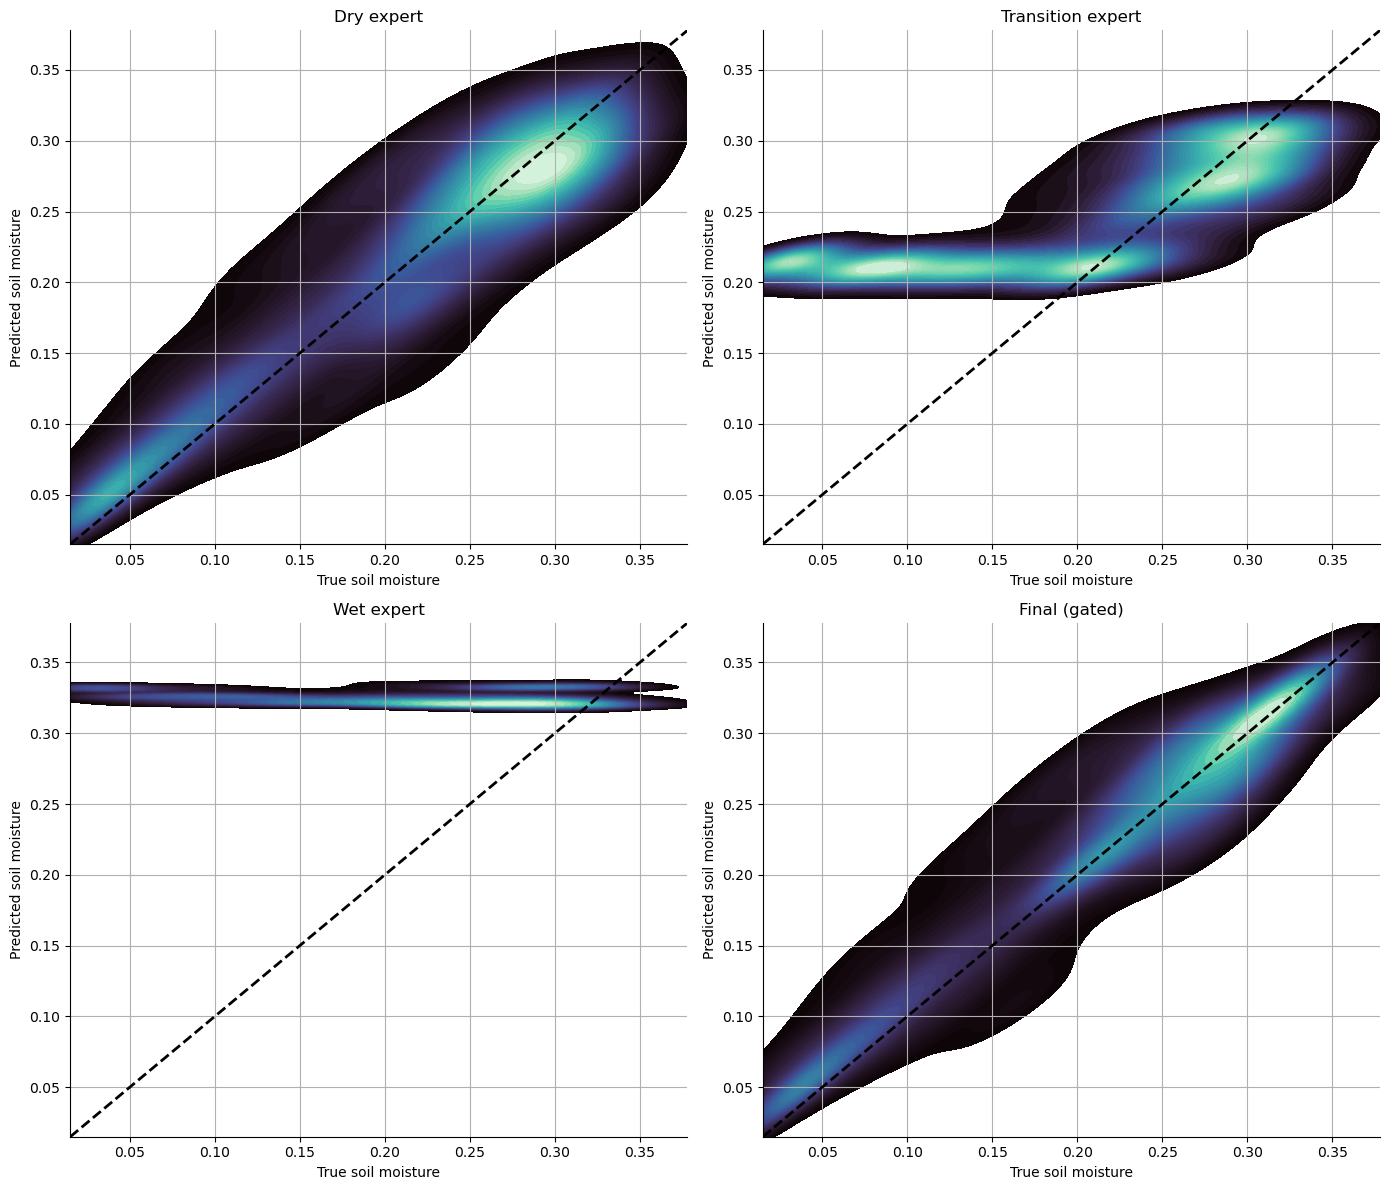

In [38]:
models = {
    "Dry expert": dfp["pred_dry"],
    "Transition expert": dfp["pred_transition"],
    "Wet expert": dfp["pred_wet"],
    "Final (gated)": dfp["pred_final"],
}

mn = min(dfp["y_true"].min(), *(v.min() for v in models.values()))
mx = max(dfp["y_true"].max(), *(v.max() for v in models.values()))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models.items()):
    sns.kdeplot(
        x=dfp["y_true"],
        y=preds,
        fill=True,
        thresh=0.05,
        levels=40,
        ax=ax,
        cmap="mako"
    )

    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=2)
    ax.set_title(name)
    ax.set_xlabel("True soil moisture")
    ax.set_ylabel("Predicted soil moisture")
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

sns.despine()
plt.tight_layout()
plt.show()

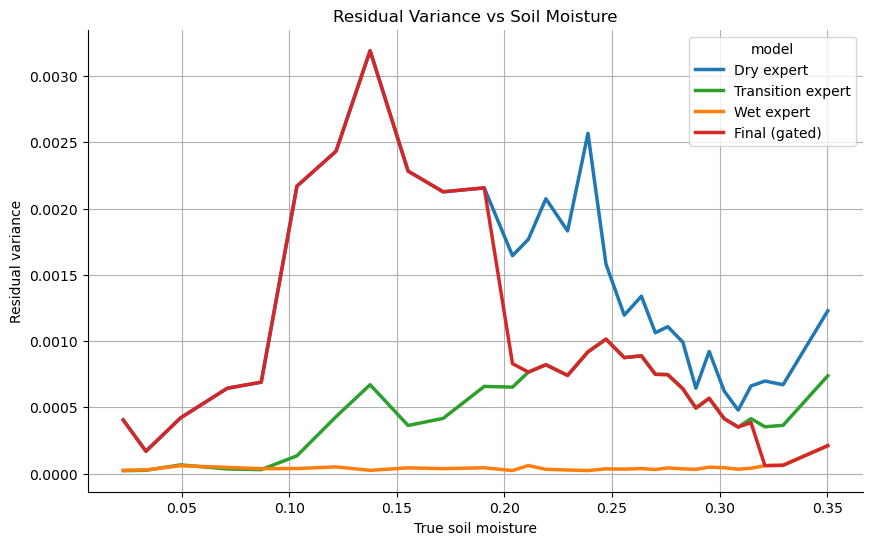

In [39]:
bins = 30
dfp["y_bin"] = pd.qcut(dfp["y_true"], q=bins, duplicates="drop")

var_df = dfp.groupby("y_bin").agg(
    y_mid=("y_true", "mean"),
    dry_var=("resid_dry", "var"),
    trans_var=("resid_transition", "var"),
    wet_var=("resid_wet", "var"),
    final_var=("resid_final", "var"),
).reset_index(drop=True)

var_long = var_df.melt(
    id_vars=["y_mid"],
    value_vars=["dry_var", "trans_var", "wet_var", "final_var"],
    var_name="model",
    value_name="variance"
)

var_long["model"] = var_long["model"].map({
    "dry_var": "Dry expert",
    "trans_var": "Transition expert",
    "wet_var": "Wet expert",
    "final_var": "Final (gated)",
})

plt.figure(figsize=(10,6))
sns.lineplot(data=var_long, x="y_mid", y="variance",
             hue="model", palette=palette, linewidth=2.5)
plt.title("Residual Variance vs Soil Moisture")
plt.xlabel("True soil moisture")
plt.ylabel("Residual variance")
sns.despine()
plt.show()

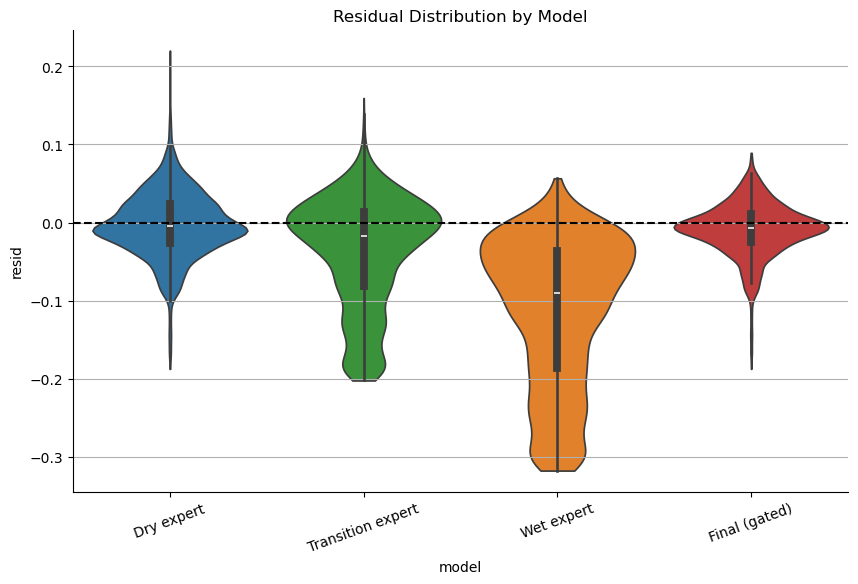

In [40]:
err_long = dfp.melt(
    value_vars=["resid_dry", "resid_transition", "resid_wet", "resid_final"],
    var_name="model",
    value_name="resid"
)

err_long["model"] = err_long["model"].map({
    "resid_dry": "Dry expert",
    "resid_transition": "Transition expert",
    "resid_wet": "Wet expert",
    "resid_final": "Final (gated)",
})

plt.figure(figsize=(10,6))
sns.violinplot(data=err_long, x="model", y="resid",
               palette=palette, cut=0)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residual Distribution by Model")
plt.xticks(rotation=20)
sns.despine()
plt.show()

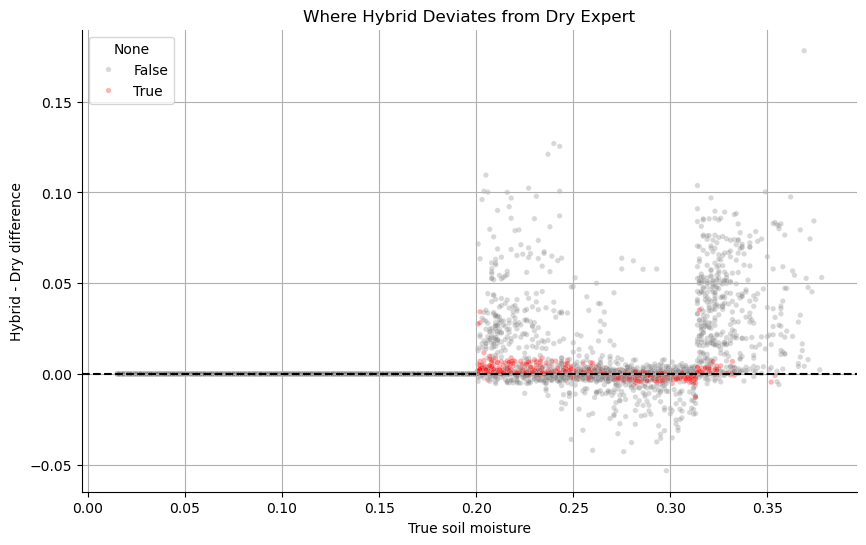

In [41]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=dfp["y_true"],
    y=dfp["pred_final"] - dfp["pred_dry"],
    hue=np.abs(dfp["resid_final"]) > np.abs(dfp["resid_dry"]),
    palette={True: "red", False: "gray"},
    alpha=0.3, s=15
)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("True soil moisture")
plt.ylabel("Hybrid - Dry difference")
plt.title("Where Hybrid Deviates from Dry Expert")
sns.despine()
plt.show()

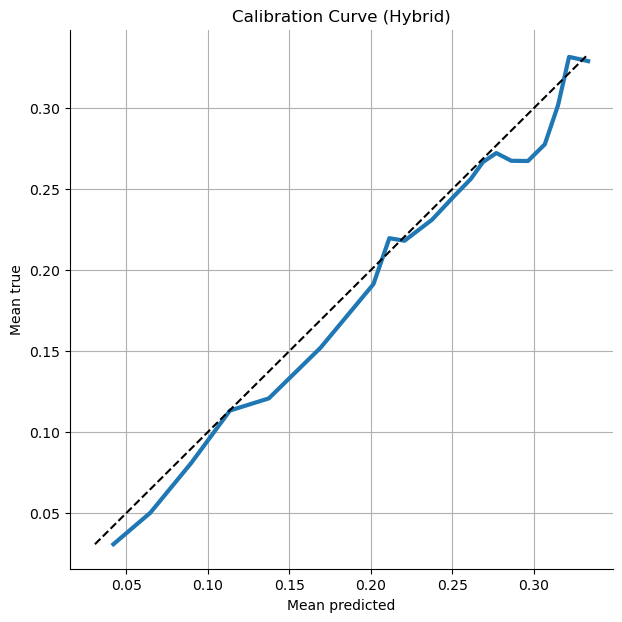

In [42]:
calib = dfp.copy()
calib["pred_bin"] = pd.qcut(calib["pred_final"], q=20, duplicates="drop")

calib_group = calib.groupby("pred_bin").agg(
    pred_mean=("pred_final", "mean"),
    true_mean=("y_true", "mean")
).reset_index(drop=True)

plt.figure(figsize=(7,7))
sns.lineplot(data=calib_group, x="pred_mean", y="true_mean", linewidth=3)
plt.plot([calib_group.min().min(), calib_group.max().max()],
         [calib_group.min().min(), calib_group.max().max()],
         linestyle="--", color="black")
plt.xlabel("Mean predicted")
plt.ylabel("Mean true")
plt.title("Calibration Curve (Hybrid)")
sns.despine()
plt.show()

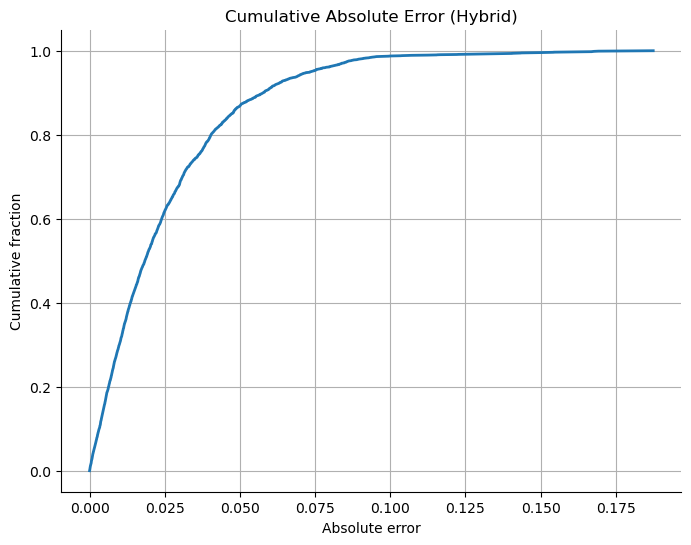

In [43]:
sorted_err = np.sort(np.abs(dfp["resid_final"]))
cdf = np.arange(len(sorted_err)) / len(sorted_err)

plt.figure(figsize=(8,6))
plt.plot(sorted_err, cdf, linewidth=2)
plt.xlabel("Absolute error")
plt.ylabel("Cumulative fraction")
plt.title("Cumulative Absolute Error (Hybrid)")
sns.despine()
plt.show()

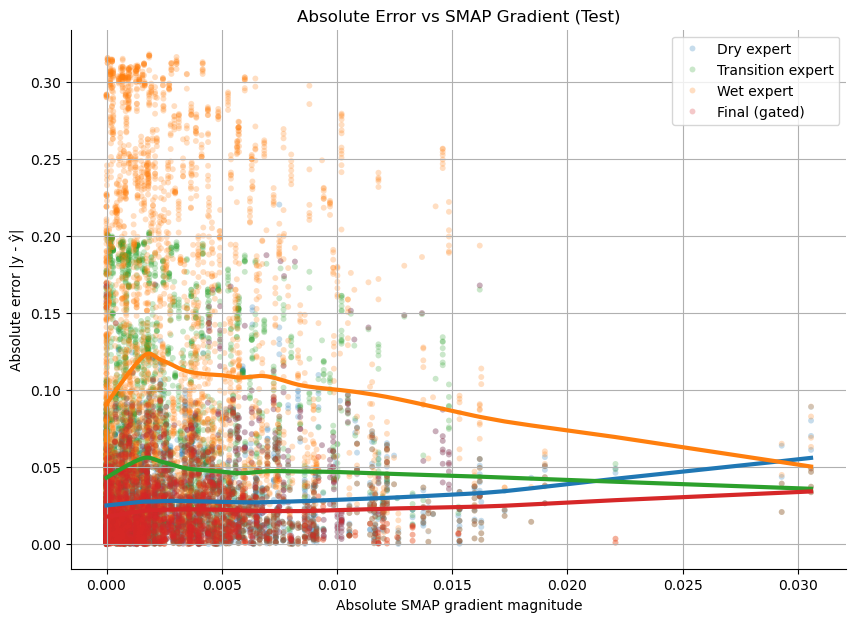

In [44]:
grad_col = None
for c in ["SMAP_sm_interp_grad7", "A_grad_SMAP_sm_interp_kobs7"]:
    if c in test_df.columns:
        grad_col = c
        break

if grad_col is not None:
    df_grad = pd.DataFrame({
        "grad_mag": np.abs(test_df[grad_col].values),
        "Dry expert": np.abs(dfp["resid_dry"]),
        "Transition expert": np.abs(dfp["resid_transition"]),
        "Wet expert": np.abs(dfp["resid_wet"]),
        "Final (gated)": np.abs(dfp["resid_final"]),
    }).melt(id_vars=["grad_mag"], var_name="model", value_name="abs_err")

    plt.figure(figsize=(10,7))
    sns.scatterplot(
        data=df_grad,
        x="grad_mag", y="abs_err",
        hue="model", palette=palette,
        alpha=0.25, s=18, linewidth=0
    )

    for m in palette.keys():
        sns.regplot(
            data=df_grad[df_grad["model"] == m],
            x="grad_mag", y="abs_err",
            scatter=False,
            lowess=True,
            color=palette[m],
            line_kws={"linewidth": 3}
        )

    plt.xlabel("Absolute SMAP gradient magnitude")
    plt.ylabel("Absolute error |y - ŷ|")
    plt.title("Absolute Error vs SMAP Gradient (Test)")
    sns.despine()
    plt.legend(title="", frameon=True)
    plt.show()

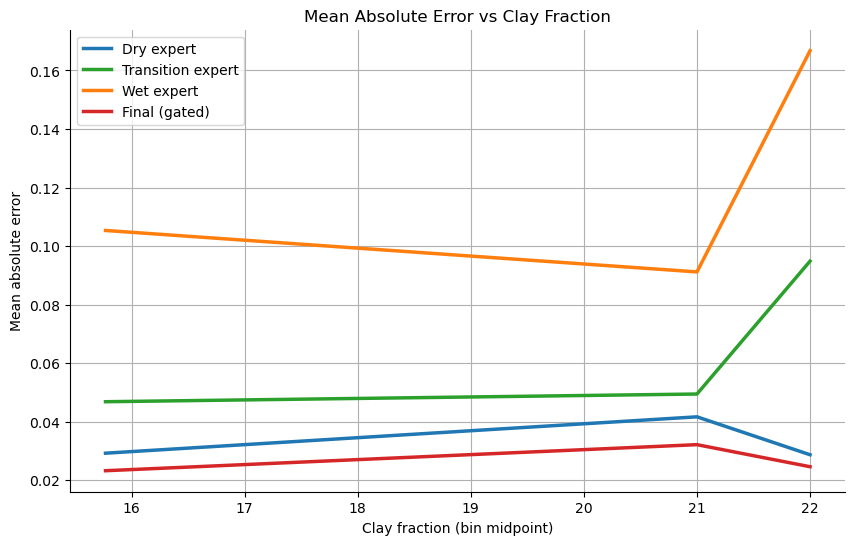

In [45]:
if "J_clay_wfrac_b0" in test_df.columns:

    df_clay = pd.DataFrame({
        "clay": test_df["J_clay_wfrac_b0"].values,
        "Dry expert": np.abs(dfp["resid_dry"]),
        "Transition expert": np.abs(dfp["resid_transition"]),
        "Wet expert": np.abs(dfp["resid_wet"]),
        "Final (gated)": np.abs(dfp["resid_final"]),
    })

    df_clay["clay_bin"] = pd.qcut(df_clay["clay"], q=20, duplicates="drop")

    clay_group = df_clay.groupby("clay_bin").agg({
        "clay": "mean",
        "Dry expert": "mean",
        "Transition expert": "mean",
        "Wet expert": "mean",
        "Final (gated)": "mean",
    }).reset_index(drop=True)

    clay_long = clay_group.melt(
        id_vars=["clay"],
        var_name="model",
        value_name="mean_abs_err"
    )

    plt.figure(figsize=(10,6))
    sns.lineplot(
        data=clay_long,
        x="clay", y="mean_abs_err",
        hue="model", palette=palette,
        linewidth=2.5
    )

    plt.xlabel("Clay fraction (bin midpoint)")
    plt.ylabel("Mean absolute error")
    plt.title("Mean Absolute Error vs Clay Fraction")
    sns.despine()
    plt.legend(title="", frameon=True)
    plt.show()

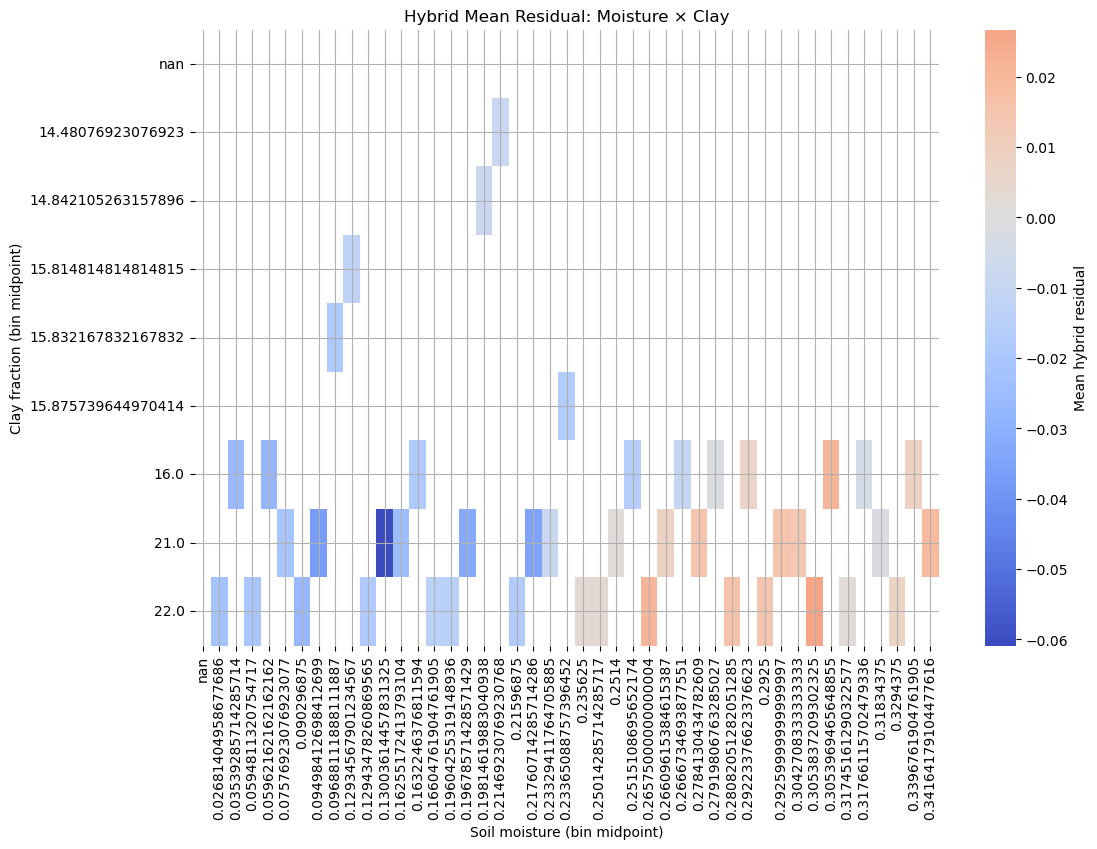

In [46]:
df2d = pd.DataFrame({
    "y_true": dfp["y_true"].values,
    "resid": dfp["resid_final"].values,
    "clay": test_df["J_clay_wfrac_b0"].values,
})

n_bins_m = 15
n_bins_c = 15

df2d["m_bin"] = pd.qcut(df2d["y_true"], q=n_bins_m, duplicates="drop")
df2d["c_bin"] = pd.qcut(df2d["clay"], q=n_bins_c, duplicates="drop")

heat = (
    df2d
    .groupby(["m_bin", "c_bin"])
    .agg(
        mean_resid=("resid", "mean"),
        count=("resid", "size"),
        m_mid=("y_true", "mean"),
        c_mid=("clay", "mean"),
    )
    .reset_index(drop=True)
)

heat_pivot = heat.pivot(
    index="c_mid",
    columns="m_mid",
    values="mean_resid"
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    heat_pivot,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Mean hybrid residual"}
)

plt.xlabel("Soil moisture (bin midpoint)")
plt.ylabel("Clay fraction (bin midpoint)")
plt.title("Hybrid Mean Residual: Moisture × Clay")
plt.show()

In [47]:
# PLAN: Targeted Moisture × Clay Interaction
#
# Observation:
# Heatmap of hybrid residuals (moisture × clay) shows:
#   - Slight overprediction in very dry soils
#   - Systematic underprediction in high moisture + high clay regions
#
# Hypothesis:
# Current model lacks curvature in the moisture–texture plane.
# Error is physically structured, not random.
#
# Plan:
# 1. Add a single interaction feature:
#       SMAP_sm_interp_ema02 * J_clay_wfrac_b0
#
# 2. Retrain base and/or wet/transition experts with this feature included.
#
# 3. Re-evaluate:
#       - R²
#       - Residual vs moisture × clay heatmap
#       - Error vs clay trend
#
# Goal:
# Introduce minimal physics-informed curvature without adding noise.
# Attempt to reduce high-clay wet-region bias and lift R² by ~0.01–0.02.

---

_Jakob Balkovec_